# Data analysis clean

## Importing packages and merging data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# reading in the data 
ai_genre_data = pd.read_csv("data_for_analysis/book_genre_ai_classified.csv", parse_dates = ["published_date", "bestsellers_date"])
decade_data = pd.read_csv("data_for_analysis/bestsellers_decade_data.csv", parse_dates = ["published_date", "bestsellers_date"])

In [3]:
# Mapping the AI guess data onto the actual data set
combined_data = pd.merge(decade_data, ai_genre_data, on="title", how="inner", suffixes=('', '_remove'))

# removing the duplicate columns
combined_data.drop([i for i in combined_data.columns if 'remove' in i],
               axis=1, inplace=True)

In [4]:
combined_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8468 entries, 0 to 8467
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Unnamed: 0.1              8468 non-null   int64         
 1   Unnamed: 0                8468 non-null   int64         
 2   age_group                 0 non-null      float64       
 3   amazon_product_url        8468 non-null   str           
 4   article_chapter_link      0 non-null      float64       
 5   asterisk                  8468 non-null   int64         
 6   author                    8468 non-null   str           
 7   book_image                8468 non-null   str           
 8   book_image_height         8468 non-null   int64         
 9   book_image_width          8468 non-null   int64         
 10  book_review_link          862 non-null    str           
 11  book_uri                  8468 non-null   str           
 12  contributor               8468 

combined_data includes all of the data from 2016-end of June 2026 with the AI's guess mapped onto it. This data set is missing a few rows because they were removed for the AI analysis as they did not have descriptions associated with each book.

The next section looks at what these missing values are.

## Investigating missing values

In [5]:
# Checking on the full data set 
full_data = pd.read_csv("raw_data/raw_data_merged.csv", parse_dates = ["published_date", "bestsellers_date"])
full_data = full_data[full_data.bestsellers_date > "2016-01-01"]
full_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8495 entries, 0 to 8494
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Unnamed: 0.1              8495 non-null   int64         
 1   Unnamed: 0                8495 non-null   int64         
 2   age_group                 0 non-null      float64       
 3   amazon_product_url        8492 non-null   str           
 4   article_chapter_link      0 non-null      float64       
 5   asterisk                  8495 non-null   int64         
 6   author                    8492 non-null   str           
 7   book_image                8492 non-null   str           
 8   book_image_height         8495 non-null   int64         
 9   book_image_width          8495 non-null   int64         
 10  book_review_link          862 non-null    str           
 11  book_uri                  8495 non-null   str           
 12  contributor               8492 

In [6]:
missing_values = full_data[full_data["description"].isna()]
missing_values

,Unnamed: 0.1,Unnamed: 0,age_group,amazon_product_url,article_chapter_link,asterisk,author,book_image,book_image_height,book_image_width,...,sunday_review_link,title,updated_date,weeks_on_list,isbns,buy_links,published_date,bestsellers_date,published_date_as_date,bestsellers_date_as_date
715,715,10,NaN,NaN,NaN,0,NaN,NaN,0,0,...,NaN,NOT QUITE DEAD YET,2026-02-24T20:40:42.812Z,2,"[{'isbn10': '', 'isbn13': '9780593977057'}]","[{'name': 'Barnes & Noble', 'url': 'https://ba...",2025-08-17,2025-08-02,2025-08-17,2025-08-02
720,720,0,NaN,NaN,NaN,0,NaN,NaN,0,0,...,NaN,THE HAMPTONS LAWYER,2026-02-24T20:40:42.555Z,1,"[{'isbn10': '', 'isbn13': '9780316569941'}]","[{'name': 'Barnes & Noble', 'url': 'https://ba...",2025-08-10,2025-07-26,2025-08-10,2025-07-26
721,721,1,NaN,NaN,NaN,0,NaN,NaN,0,0,...,NaN,NOT QUITE DEAD YET,2026-02-24T20:40:42.812Z,1,"[{'isbn10': '', 'isbn13': '9780593977057'}]","[{'name': 'Barnes & Noble', 'url': 'https://ba...",2025-08-10,2025-07-26,2025-08-10,2025-07-26
7532,7532,17,NaN,https://www.amazon.com/When-All-Girls-Have-Gon...,NaN,0,Jayne Ann Krentz,https://static01.nyt.com/bestsellers/images/97...,495,328,...,NaN,WHEN ALL THE GIRLS HAVE GONE,2026-03-18T00:22:17.499Z,0,"[{'isbn10': '', 'isbn13': '9780698193673'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2016-12-18,2016-12-03,2016-12-18,2016-12-03
7573,7573,18,NaN,https://www.amazon.com/Sweet-Cheeks-K-Bromberg...,NaN,0,K. Bromberg,https://static01.nyt.com/bestsellers/images/97...,495,330,...,NaN,SWEET CHEEKS,2026-03-18T00:22:13.92Z,0,"[{'isbn10': '', 'isbn13': '9781942832034'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2016-12-04,2016-11-19,2016-12-04,2016-11-19
7613,7613,18,NaN,https://www.amazon.com/Shadow-Victory-Honor-Ha...,NaN,0,David Weber,https://static01.nyt.com/bestsellers/images/97...,495,326,...,NaN,SHADOW OF VICTORY,2026-03-18T00:20:35.366Z,0,"[{'isbn10': '', 'isbn13': '9781625795465'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2016-11-20,2016-11-05,2016-11-20,2016-11-05
7614,7614,19,NaN,https://www.amazon.com/Mr-President-White-Hous...,NaN,0,Katy Evans,https://static01.nyt.com/bestsellers/images/97...,495,310,...,NaN,MR. PRESIDENT,2026-03-18T00:20:35.51Z,0,"[{'isbn10': '', 'isbn13': '9780997263633'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2016-11-20,2016-11-05,2016-11-20,2016-11-05
7634,7634,19,NaN,https://www.amazon.com/Marriage-Games-Duet-Boo...,NaN,0,C. D. Reiss,https://static01.nyt.com/bestsellers/images/97...,495,325,...,NaN,MARRIAGE GAMES,2026-03-18T00:21:08.211Z,0,"[{'isbn10': '', 'isbn13': '9781942833284'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2016-11-13,2016-10-29,2016-11-13,2016-10-29
7711,7711,16,NaN,http://www.amazon.com/Want-Start-Scandal-Castl...,NaN,0,Tessa Dare,https://static01.nyt.com/bestsellers/images/97...,495,299,...,NaN,DO YOU WANT TO START A SCANDAL,2026-03-18T00:18:51.065Z,0,"[{'isbn10': '', 'isbn13': '9780062349057'}]","[{'name': 'Amazon', 'url': 'http://www.amazon....",2016-10-16,2016-10-01,2016-10-16,2016-10-01
7712,7712,17,NaN,http://www.amazon.com/Trouble-Mistletoe-Heartb...,NaN,0,Jill Shalvis,https://static01.nyt.com/bestsellers/images/97...,495,328,...,NaN,THE TROUBLE WITH MISTLETOE,2026-03-18T00:18:51.216Z,0,"[{'isbn10': '', 'isbn13': '9780062448057'}]","[{'name': 'Amazon', 'url': 'http://www.amazon....",2016-10-16,2016-10-01,2016-10-16,2016-10-01


In [7]:
len(missing_values)

27

There are 27 books that are not included in our analysis, most of them from 2016, but spread throughout the year

## Checking romance trends

### Annual

In [8]:
annual_genre_breakdown = combined_data.groupby(combined_data.bestsellers_date.dt.year).ai_guess.value_counts().unstack().reset_index()
annual_genre_breakdown["romance_percent"] = (annual_genre_breakdown["genre_is_romance"]/(annual_genre_breakdown["genre_is_not_romance"] + annual_genre_breakdown["genre_is_romance"])*100) 

In [9]:
annual_genre_breakdown

ai_guess,bestsellers_date,genre_is_not_romance,genre_is_romance,romance_percent
0,2016,835,201,19.401544
1,2017,724,66,8.354430
2,2018,703,77,9.871795
3,2019,729,51,6.538462
4,2020,718,62,7.948718
5,2021,646,134,17.179487
6,2022,540,255,32.075472
7,2023,570,210,26.923077
8,2024,637,143,18.333333
9,2025,635,142,18.275418


<Axes: xlabel='bestsellers_date'>

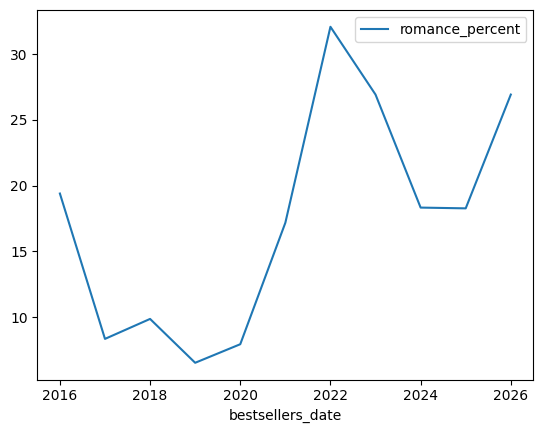

In [10]:
annual_genre_breakdown.plot(x='bestsellers_date', y='romance_percent')

### Monthly

In [11]:
# Let's see if there is anything seasonal about this
monthly_genre_breakdown = combined_data.groupby(combined_data.bestsellers_date.dt.to_period("M")).ai_guess.value_counts().unstack().reset_index()
monthly_genre_breakdown["bestsellers_date"] = (
    monthly_genre_breakdown["bestsellers_date"].dt.to_timestamp()
)
monthly_genre_breakdown["romance_percent"] = (monthly_genre_breakdown["genre_is_romance"]/(monthly_genre_breakdown["genre_is_not_romance"] + monthly_genre_breakdown["genre_is_romance"])*100) 

<Axes: xlabel='bestsellers_date'>

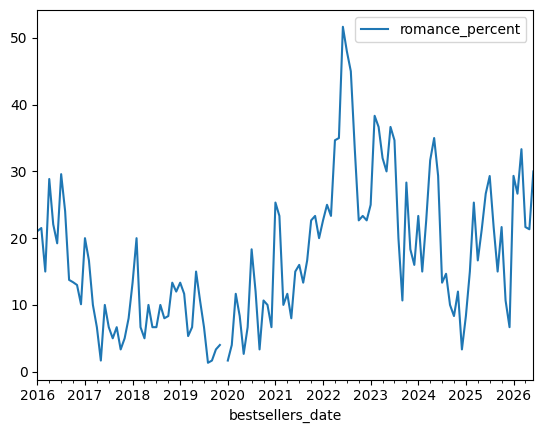

In [12]:
monthly_genre_breakdown.plot(x='bestsellers_date', y='romance_percent')

In [13]:
# Getting a subset of the data for the first chart in the story and exporting it
chart1 = monthly_genre_breakdown[monthly_genre_breakdown["bestsellers_date"].dt.year<2026]
chart1.to_csv("chart_data/chart1.csv")

In [16]:
# Getting a subset of the data for the last chart in the story and exporting it
chart_kicker = monthly_genre_breakdown
chart_kicker.to_csv("chart_data/chart_kicker.csv")

Note, the data break at the end of 2019 is actually a 0 value - I check manually and in the month of December 2019 there were no romance novels on the list, resulting in a missing value due to the way I calculated the percentage. I replaced this with a 0 when making the chart in datawrapper

## Overall share of bestseller spots

In [14]:
# The number of spots available in total between 2016 and 2025
full_year_data_w_missing_values = full_data[full_data.bestsellers_date.dt.year < 2026]
len(full_year_data_w_missing_values)

8105

In [15]:
# The number of spots classified by my ai model between 2016 and 2025
full_year_data = combined_data[combined_data.bestsellers_date.dt.year < 2026]
len(full_year_data)

8078

In [16]:
# The number of those spots taken up by romance novels vs not
full_year_data["ai_guess"].value_counts()

ai_guess
genre_is_not_romance    6737
genre_is_romance        1341
Name: count, dtype: int64

In [17]:
6737+1341

8078

In [18]:
# The overall percentage of spots taken up by romance books
1341/8078*100

16.600643723693985

## Overall share of bestseller books

In [19]:
# the number of unique books analysed but this is for the whole time
full_year_data['title'].nunique()

2137

In [20]:
# Getting the unique titles
unique_titles_df = full_year_data.drop_duplicates(subset="title")

In [21]:
len(unique_titles_df)

2137

In [22]:
# Getting the breakdown of titles
unique_titles_df["ai_guess"].value_counts()

ai_guess
genre_is_not_romance    1711
genre_is_romance         426
Name: count, dtype: int64

In [23]:
# Percentage of books that appeared on the list between 2016 and 2025 inclusive that were classified as romance
426/2137*100

19.934487599438466

This will be the next chart. Can just be a stacked bar if things get dire or just not exist

## Top performing titles

In [33]:
# You want a subset with only romances
# So you are going to need the full year data 
full_year_data.title.value_counts().head(10).reset_index()

,title,count
0,WHERE THE CRAWDADS SING,193
1,IT ENDS WITH US,147
2,THE SEVEN HUSBANDS OF EVELYN HUGO,115
3,THE HOUSEMAID,111
4,FOURTH WING,104
5,VERITY,96
6,LITTLE FIRES EVERYWHERE,81
7,IRON FLAME,71
8,THE TATTOOIST OF AUSCHWITZ,70
9,UGLY LOVE,66


In [34]:
top_10 = full_year_data.title.value_counts().head(10).reset_index()

In [35]:
top_10.to_csv("chart_data/top_10.csv")

In [36]:
# Top performing romances
romance_only = full_year_data[full_year_data.ai_guess == "genre_is_romance"]

In [37]:
len(romance_only)

1341

In [38]:
romance_only.title.value_counts().head(10).reset_index()

title
THE SEVEN HUSBANDS OF EVELYN HUGO    115
UGLY LOVE                             66
IT STARTS WITH US                     59
ICEBREAKER                            41
PEOPLE WE MEET ON VACATION            38
NOVEMBER 9                            35
ME BEFORE YOU                         33
LIGHTS OUT                            27
A COURT OF SILVER FLAMES              22
HAPPY PLACE                           22
Name: count, dtype: int64

In [39]:
top_10_romance = romance_only.title.value_counts().head(10).reset_index()
top_10_romance.to_csv("chart_data/top_10_romance.csv")

## Top performing authors

In [52]:
full_year_data.author.value_counts().head(10)

author
Colleen Hoover         446
John Grisham           254
Freida McFadden        208
Rebecca Yarros         206
Delia Owens            193
Taylor Jenkins Reid    167
David Baldacci         166
Kristin Hannah         165
Sarah J. Maas          141
Stephen King           141
Name: count, dtype: int64

In [53]:
romance_only.author.value_counts().head(10)

author
Colleen Hoover         188
Taylor Jenkins Reid    115
Emily Henry             99
Nicholas Sparks         65
Jojo Moyes              56
Julia Quinn             51
Ali Hazelwood           50
Hannah Grace            50
Carley Fortune          37
Sarah J. Maas           36
Name: count, dtype: int64

### When authors appeared on the list

In [40]:
# We want a line chart with Colleen hoover's romance titles. So first you are subsetting for her, then you are grouping by title
# Then we want 
hoover = romance_only[romance_only["author"] == "Colleen Hoover"]

In [56]:
hoover.bestsellers_date.min()

Timestamp('2018-07-21 00:00:00')

In [48]:
# Some way to show 
henry = romance_only[romance_only["author"] == "Emily Henry"]

In [57]:
henry.bestsellers_date.min()

Timestamp('2020-05-23 00:00:00')

In [51]:
reid = romance_only[romance_only["author"] == "Taylor Jenkins Reid"]

In [58]:
reid.bestsellers_date.min()

Timestamp('2021-06-26 00:00:00')

In [54]:
sparks = romance_only[romance_only["author"] == "Nicholas Sparks"]

In [55]:
sparks.bestsellers_date.min()

Timestamp('2016-01-02 00:00:00')

### Exploring the peak in June 2022

In [59]:
# So I want the peak of June 2022. # First we want to isolate those from the overall data 
june_2022 = full_year_data[
    (full_year_data["bestsellers_date"].dt.year == 2022) &
    (full_year_data["bestsellers_date"].dt.month == 6)
]


In [61]:
romance_j_22 = june_2022[june_2022["ai_guess"] == "genre_is_romance"]

In [64]:
romance_j_22.groupby("author").title.value_counts()

author               title                            
Carley Fortune       EVERY SUMMER AFTER                   2
Colleen Hoover       UGLY LOVE                            4
                     NOVEMBER 9                           4
                     ALL YOUR PERFECTS                    2
Emily Giffin         MEANT TO BE                          2
Emily Henry          BOOK LOVERS                          4
                     PEOPLE WE MEET ON VACATION           4
                     BEACH READ                           4
Katee Robert         WICKED BEAUTY                        1
Taylor Jenkins Reid  THE SEVEN HUSBANDS OF EVELYN HUGO    4
Name: count, dtype: int64